In [ ]:
%pip install brian2
from brian2 import *
import matplotlib.pyplot as plt
import numpy as np


# ============================================================
# 1. EASY PARAMETERS TO CHANGE
# ============================================================

# --- Network ---
N_E = 2000
N_I = 500

# --- Neuron ---
tau_m = 20*ms

# --- Synapse ---
tau_syn = 5*ms
# tau_syn = 50*ms

# --- Strength of inhibition ---
g = 4.5
# g = 2
# g = 6

# --- External input ---
#input_level = 0.9
input_level = 1.05

# --- Adaptation ---
adaptation_strength = 0*mV
# adaptation_strength = 5*mV


# ============================================================
# 2. FIXED PARAMETERS
# ============================================================

N = N_E + N_I

epsilon = 0.1

theta = 20*mV
V_r = 10*mV

J = 0.1*mV

delay = 1.5*ms
refractory = 2*ms

C_ext = int(epsilon*N_E)

# External input that would produce threshold
nu_thr = theta / (J * C_ext * tau_m)



   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 57.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 30.1 MB/s eta 0:00:00


In [ ]:
# ============================================================
# 3. FUNCTION TO RUN ONE NETWORK
# ============================================================

def run_network(
    input_level,
    tau_syn,
    g,
    adaptation_strength,
    sim_time=1*second,
    record_spikes=True,
    modulation_frequency=None,
    modulation_depth=0.0
):

    start_scope()

    # --------------------------------------------------------
    # External input
    # --------------------------------------------------------

    external_rate = input_level * nu_thr

    # --------------------------------------------------------
    # Sinusoidal modulation
    #
    # modulation_depth = fraction of the mean input
    #
    # Example:
    # modulation_depth = 0.05
    # means a 5% modulation
    # --------------------------------------------------------

    if modulation_frequency is not None:

        Iamp = (
            modulation_depth
            * tau_m
            * J
            * C_ext
            * external_rate
        )

        frequency = modulation_frequency

    else:

        Iamp = 0*mV
        frequency = 1*Hz

    # --------------------------------------------------------
    # Neuron equations
    # --------------------------------------------------------

    equations = '''
    dv/dt = (
        -v
        + s_e
        + s_i
        + Iamp*sin(2*pi*frequency*t)
        - w
    ) / tau_m : volt

    ds_e/dt = -s_e/tau_syn : volt

    ds_i/dt = -s_i/tau_syn : volt

    dw/dt = -w/tau_m : volt

    Iamp : volt
    frequency : Hz
    '''

    neurons = NeuronGroup(
        N,
        equations,
        threshold='v > theta',
        reset='''
        v = V_r
        w += adaptation_strength
        ''',
        refractory=refractory,
        method='euler',
        namespace={
            'tau_m': tau_m,
            'tau_syn': tau_syn,
            'theta': theta,
            'V_r': V_r,
            'refractory': refractory,
            'adaptation_strength': adaptation_strength
        }
    )

    # Initial conditions
    neurons.v = V_r
    neurons.s_e = 0*mV
    neurons.s_i = 0*mV
    neurons.w = 0*mV

    # Set modulation parameters
    neurons.Iamp = Iamp
    neurons.frequency = frequency

    # --------------------------------------------------------
    # Excitatory / inhibitory neurons
    # --------------------------------------------------------

    E = neurons[:N_E]
    I = neurons[N_E:]

    # --------------------------------------------------------
    # Excitatory synapses
    # --------------------------------------------------------

    exc_synapses = Synapses(
        E,
        neurons,
        on_pre='s_e += J',
        delay=delay,
        namespace={'J': J}
    )

    exc_synapses.connect(p=epsilon)

    # --------------------------------------------------------
    # Inhibitory synapses
    # --------------------------------------------------------

    inh_synapses = Synapses(
        I,
        neurons,
        on_pre='s_i -= g*J',
        delay=delay,
        namespace={
            'g': g,
            'J': J
        }
    )

    inh_synapses.connect(p=epsilon)

    # --------------------------------------------------------
    # Constant Poisson background input
    # --------------------------------------------------------

    external_input = PoissonInput(
        neurons,
        target_var='v',
        N=C_ext,
        rate=external_rate,
        weight=J
    )

    # --------------------------------------------------------
    # Record population firing rate
    # --------------------------------------------------------

    rate_monitor = PopulationRateMonitor(neurons)

    # --------------------------------------------------------
    # Optional spike recording
    # --------------------------------------------------------

    if record_spikes:
        spike_monitor = SpikeMonitor(neurons)
    else:
        spike_monitor = None

    # --------------------------------------------------------
    # Run
    # --------------------------------------------------------

    run(sim_time)

    return rate_monitor, spike_monitor


def create_amplitude_spectrum(
    tau_syn,
    g,
    adaptation_strength,
    input_level=1.0,
    sim_time=4*second,
    transient=1*second
):

    # --------------------------------------------------------
    # Run network ONCE
    # Constant-rate random Poisson input, NO oscillation
    # --------------------------------------------------------

    monitor, spm = run_network(
        input_level=input_level,
        tau_syn=tau_syn,
        g=g,
        adaptation_strength=adaptation_strength,
        sim_time=sim_time,
        record_spikes=True,
        modulation_frequency=None,   # IMPORTANT: no oscillatory input
        modulation_depth=0.0
    )

    # --------------------------------------------------------
    # Get population firing rate
    # --------------------------------------------------------

    t = np.asarray(monitor.t / second)
    rate = np.asarray(monitor.rate / Hz)

    # --------------------------------------------------------
    # Remove transient
    # --------------------------------------------------------

    mask = t >= float(transient / second)

    t = t[mask]
    rate = rate[mask]

    # --------------------------------------------------------
    # Remove mean firing rate
    # --------------------------------------------------------

    rate_centered = rate - np.mean(rate)

    # --------------------------------------------------------
    # Fourier transform
    # --------------------------------------------------------

    N_samples = len(rate_centered)

    dt = np.mean(np.diff(t))

    fft_values = np.fft.rfft(rate_centered)

    fft_frequencies = np.fft.rfftfreq(
        N_samples,
        d=dt
    )

    # --------------------------------------------------------
    # Amplitude spectrum
    # --------------------------------------------------------

    amplitude_spectrum = (
        2.0 / N_samples
    ) * np.abs(fft_values)

    # Normalize spectrum
    amplitude_spectrum = (
        amplitude_spectrum
        / np.sum(amplitude_spectrum)
    )

    return (
        fft_frequencies,
        amplitude_spectrum,
        spm
    )

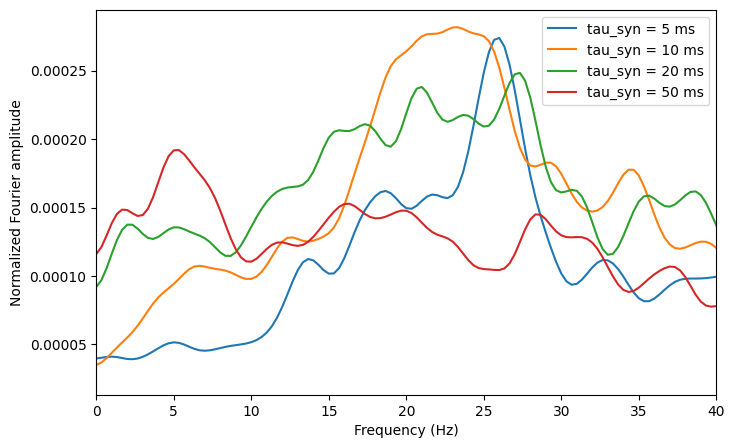

In [ ]:
tau_syn_values = [5, 10, 20, 50] * ms

plt.figure(figsize=(8, 5))

for tau_syn_value in tau_syn_values:

    frequencies, amplitudes, _ = create_amplitude_spectrum(
        tau_syn=tau_syn_value,
        g=g,
        adaptation_strength=adaptation_strength,
        input_level=input_level
    )

    # Smooth the Fourier spectrum
    amplitudes_smooth = gaussian_filter1d(amplitudes, sigma=3)

    plt.plot(
        frequencies,
        amplitudes_smooth,
        label=f'tau_syn = {tau_syn_value/ms:.0f} ms'
    )

plt.xlabel('Frequency (Hz)')
plt.ylabel('Normalized Fourier amplitude')
plt.legend()
plt.xlim(0, 40)
plt.show()

In [ ]:
# Use only frequencies from 0–40 Hz
mask = (frequencies > 0) & (frequencies <= 40)

# Fourier amplitude in this frequency range
amp = amplitudes[mask]

# Convert amplitude to power
power = amp ** 2

# Convert power to proportions: p_i
p = power / np.sum(power)

# Spectral entropy: -sum(p log p)
H = -np.sum(p * np.log(p + 1e-12))

# Normalize entropy to range 0–1
H_norm = H / np.log(len(p))

print(
    f"tau_syn = {tau_syn_value/ms:.0f} ms: "
    f"spectral entropy = {H_norm:.4f}"
)




tau_syn = 50 ms: spectral entropy = 0.9168


tau_syn = 5 ms: spectral entropy = 0.8092
tau_syn = 10 ms: spectral entropy = 0.8279
tau_syn = 20 ms: spectral entropy = 0.9080
tau_syn = 50 ms: spectral entropy = 0.8399


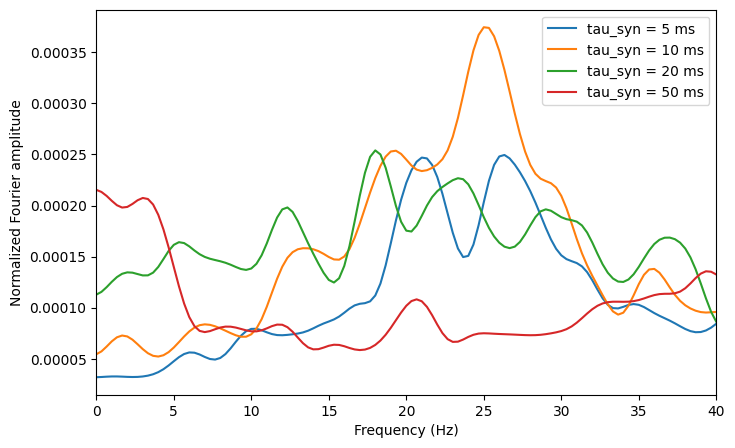

In [ ]:
from scipy.ndimage import gaussian_filter1d

tau_syn_values = [5, 10, 20, 50] * ms

plt.figure(figsize=(8, 5))

for tau_syn_value in tau_syn_values:

    frequencies, amplitudes, _ = create_amplitude_spectrum(
        tau_syn=tau_syn_value,
        g=g,
        adaptation_strength=adaptation_strength,
        input_level=input_level
    )

    # ---------------------------------------
    # SPECTRAL ENTROPY
    # ---------------------------------------

    # Analyze only 0–40 Hz
    mask = (frequencies > 0) & (frequencies <= 40)

    # Power at each frequency
    power = amplitudes[mask] ** 2

    # Proportion of total power at each frequency
    p = power / np.sum(power)

    # Spectral entropy
    H = -np.sum(p * np.log(p + 1e-12))

    # Normalize entropy between 0 and 1
    H_norm = H / np.log(len(p))

    print(
        f"tau_syn = {tau_syn_value/ms:.0f} ms: "
        f"spectral entropy = {H_norm:.4f}"
    )

    # ---------------------------------------
    # PLOT SPECTRUM
    # ---------------------------------------

    amplitudes_smooth = gaussian_filter1d(amplitudes, sigma=3)

    plt.plot(
        frequencies,
        amplitudes_smooth,
        label=f'tau_syn = {tau_syn_value/ms:.0f} ms'
    )


plt.xlabel('Frequency (Hz)')
plt.ylabel('Normalized Fourier amplitude')
plt.xlim(0, 40)
plt.legend()
plt.show()

In [ ]:
# ============================================================
# CREATE AMPLITUDE SPECTRUM
# ============================================================

frequencies, amplitudes,spike_monitors = create_amplitude_spectrum(
    tau_syn=tau_syn,
    g=g,
    adaptation_strength=adaptation_strength,
    input_level=input_level,
    modulation_depth=0.05
)


Frequency: 1.0 Hz

Frequency: 2.0 Hz

Frequency: 5.0 Hz

Frequency: 10.0 Hz

Frequency: 20.0 Hz

Frequency: 40.0 Hz

Frequency: 80.0 Hz

Frequency: 160.0 Hz


In [ ]:
# spike_monitors[0]

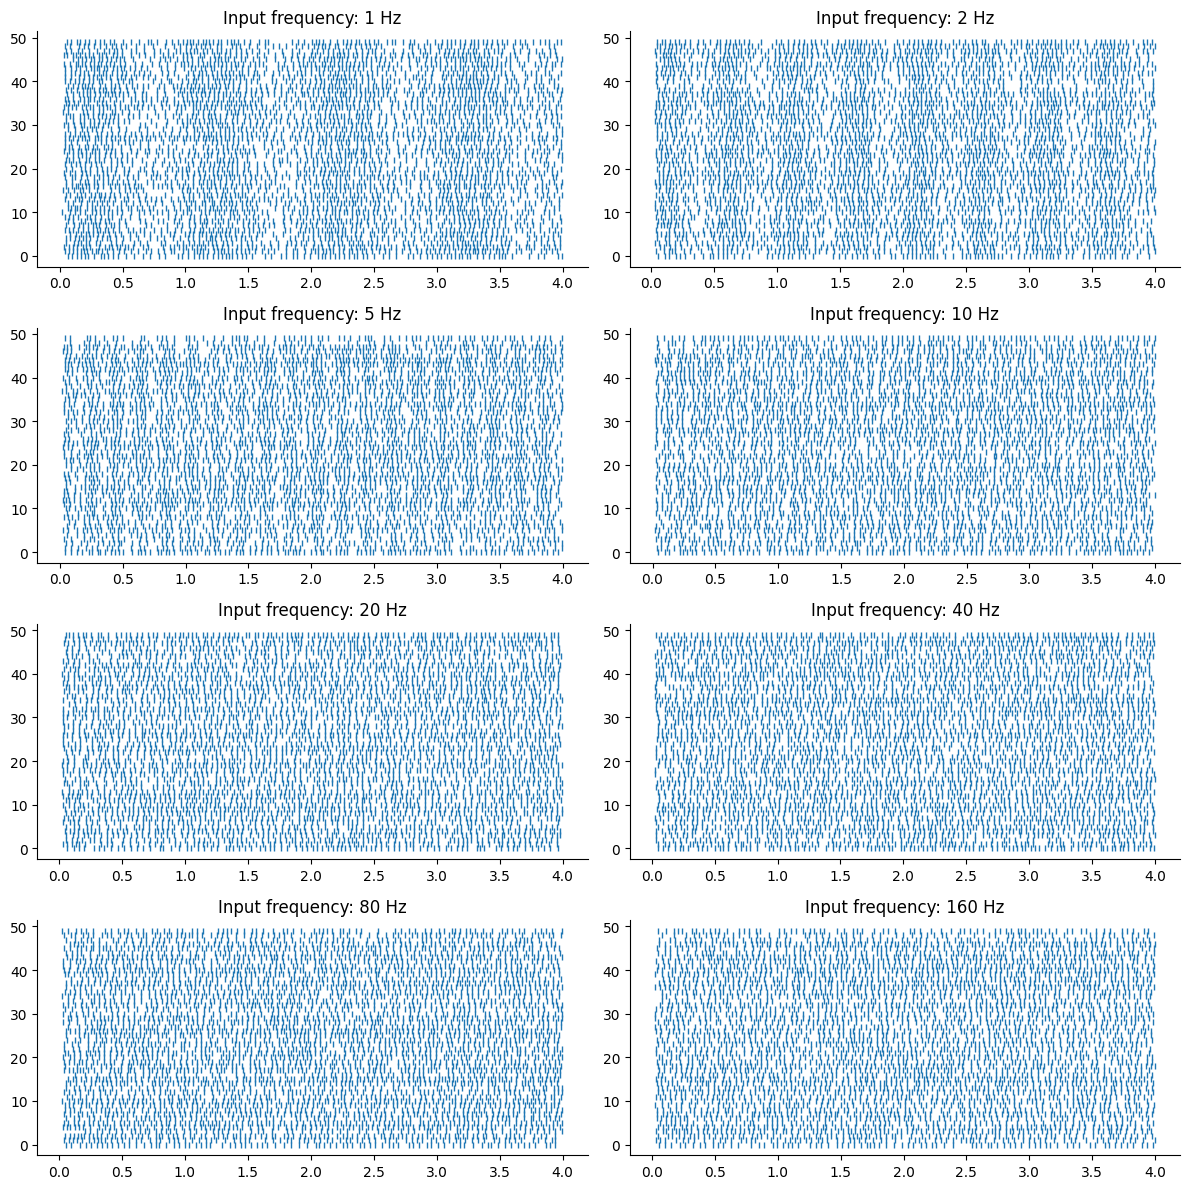

In [ ]:
fig,ax = plt.subplots(4,2,figsize=(12,12))
input_freqs = np.array([1, 2, 5, 10, 20, 40, 80, 160])
all_axes = np.hstack(ax)
for i,freq in enumerate(input_freqs):
    sp_m = spike_monitors[i]
    all_axes[i].plot(sp_m.t/second, sp_m.i,'|',ms=5)
    all_axes[i].set_title("Input frequency: "+str(freq)+" Hz")
    all_axes[i].spines.top.set_visible(False)
    all_axes[i].spines.right.set_visible(False)
    #all_axes[i].set_xlim(1.0,1.5) # zoom in ?
plt.tight_layout()


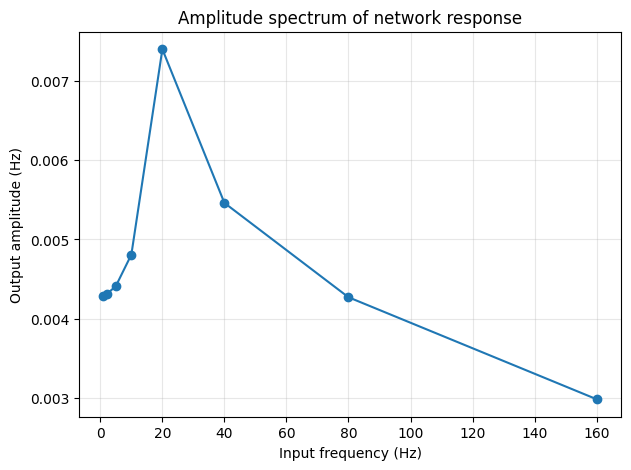

In [ ]:
plt.figure(figsize=(7, 5))

# plt.semilogx(
#     frequencies,
#     amplitudes,
#     'o-'
# )
plt.plot(frequencies,amplitudes,'o-')
plt.xlabel(
    'Input frequency (Hz)'
)

plt.ylabel(
    'Output amplitude (Hz)'
)

plt.title(
    'Amplitude spectrum of network response'
)

plt.grid(True, alpha=0.3)

plt.show()

In [ ]:
import pandas as pd
import seaborn as sns

In [ ]:
# ============================================================
# 7. CALCULATE THE INPUT-OUTPUT CURVE
#    FOR YOUR CURRENT PARAMETERS
# ============================================================

# g = 4.5, tau_syn = 5.0*ms
gs = [4.5]
tau_syns = [5.0, 50]
adapt_strengs = [0,  5]

# input_values = dict()
# output_values = dict()
all_sims = pd.DataFrame()

for g in gs:
    for tau_syn in tau_syns:
        for adaptation_strength in adapt_strengs:
            print(g,tau_syn,adaptation_strength)
            #input_val, output_val = calculate_input_output_curve(tau_syn=tau_syn*ms,g=g,adaptation_strength=adaptation_strength*mV)
            frequencies, amplitudes,_ = create_amplitude_spectrum(tau_syn=tau_syn*ms,g=g,adaptation_strength=adaptation_strength*mV,input_level=input_level,modulation_depth=0.05)
            temp = pd.DataFrame()
            temp['input_frequencies'] = frequencies
            temp['output_amplitude'] = amplitudes
            temp['g'] = g
            temp[r'$\tau_{syn}$'] = tau_syn
            temp['adaptation_strength'] = adaptation_strength
            all_sims = pd.concat([all_sims,temp])
#             input_values[(g,tau_syn,adaptation_strength)] = input_val
#             output_values[(g,tau_syn,adaptation_strength)] = output_val




4.5 5.0 0

Frequency: 1.0 Hz

Frequency: 2.0 Hz

Frequency: 5.0 Hz

Frequency: 10.0 Hz

Frequency: 20.0 Hz

Frequency: 40.0 Hz

Frequency: 80.0 Hz

Frequency: 160.0 Hz
4.5 5.0 5

Frequency: 1.0 Hz

Frequency: 2.0 Hz

Frequency: 5.0 Hz

Frequency: 10.0 Hz

Frequency: 20.0 Hz

Frequency: 40.0 Hz

Frequency: 80.0 Hz

Frequency: 160.0 Hz
4.5 50 0

Frequency: 1.0 Hz

Frequency: 2.0 Hz

Frequency: 5.0 Hz

Frequency: 10.0 Hz

Frequency: 20.0 Hz

Frequency: 40.0 Hz

Frequency: 80.0 Hz

Frequency: 160.0 Hz
4.5 50 5

Frequency: 1.0 Hz

Frequency: 2.0 Hz

Frequency: 5.0 Hz

Frequency: 10.0 Hz

Frequency: 20.0 Hz

Frequency: 40.0 Hz

Frequency: 80.0 Hz

Frequency: 160.0 Hz
2.0 5.0 0

Frequency: 1.0 Hz

Frequency: 2.0 Hz

Frequency: 5.0 Hz

Frequency: 10.0 Hz

Frequency: 20.0 Hz

Frequency: 40.0 Hz

Frequency: 80.0 Hz

Frequency: 160.0 Hz
2.0 5.0 5

Frequency: 1.0 Hz

Frequency: 2.0 Hz

Frequency: 5.0 Hz

Frequency: 10.0 Hz

Frequency: 20.0 Hz

Frequency: 40.0 Hz

Frequency: 80.0 Hz

Frequency: 160

In [ ]:
all_sims

,input_frequencies,output_amplitude,g,$\tau_{syn}$,adaptation_strength
0,1.0,0.004270,4.5,5.0,0
1,2.0,0.004360,4.5,5.0,0
2,5.0,0.004408,4.5,5.0,0
3,10.0,0.004939,4.5,5.0,0
4,20.0,0.007384,4.5,5.0,0
...,...,...,...,...,...
3,10.0,0.005171,6.0,50.0,5
4,20.0,0.004919,6.0,50.0,5
5,40.0,0.003489,6.0,50.0,5
6,80.0,0.002314,6.0,50.0,5


In [ ]:
lif_sims = all_sims[all_sims['adaptation_strength']==0]
adap_sims = all_sims[all_sims['adaptation_strength']>0]

In [ ]:
def plot_amplitude_curve(data):

    fig,ax = plt.subplots(1,2,figsize=(12,8))

    for i,grp in enumerate(data.groupby(r'$\tau_{syn}$')):
        tit = r'$\tau_{syn}$'+" = "+str(grp[0])
        sub_data = grp[1].copy()
        for g_dat in sub_data.groupby('g'):
            ax[i].plot(g_dat[1]['input_frequencies'],g_dat[1]['output_amplitude'],'o-',label='g = '+str(g_dat[0]))
        ax[i].legend()
        ax[i].set_title(tit)
        ax[i].spines.top.set_visible(False)
        ax[i].spines.right.set_visible(False)
        ax[i].set_xlabel("Input frequencies")
        ax[i].set_ylabel("Output amplitude")
        ax[i].grid(alpha=0.3)



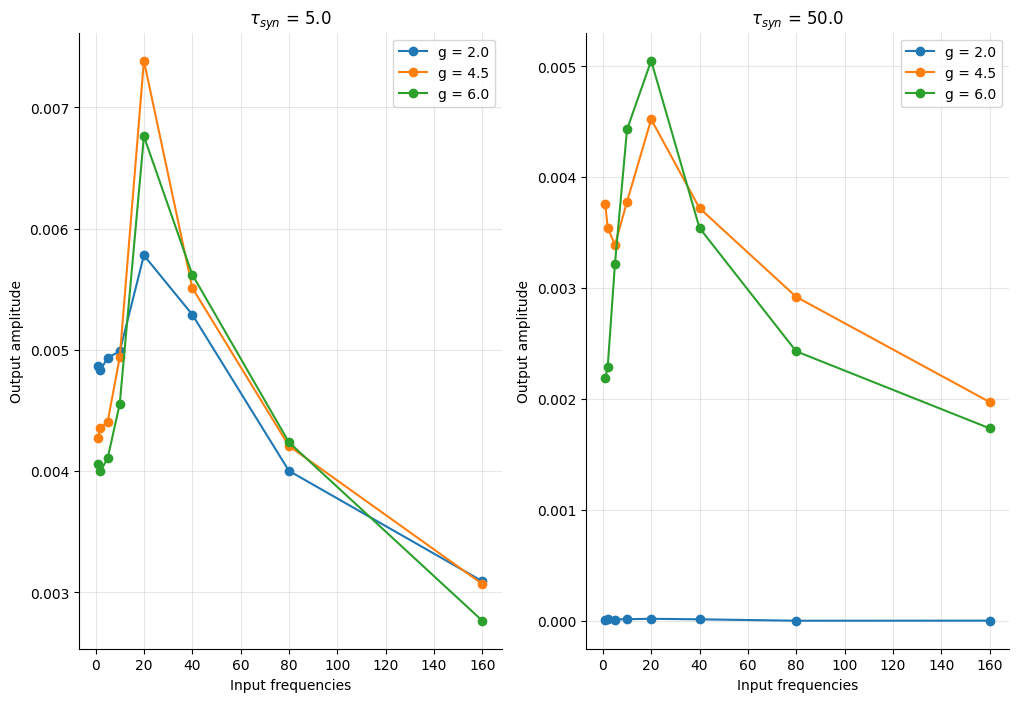

In [ ]:
plot_amplitude_curve(lif_sims)

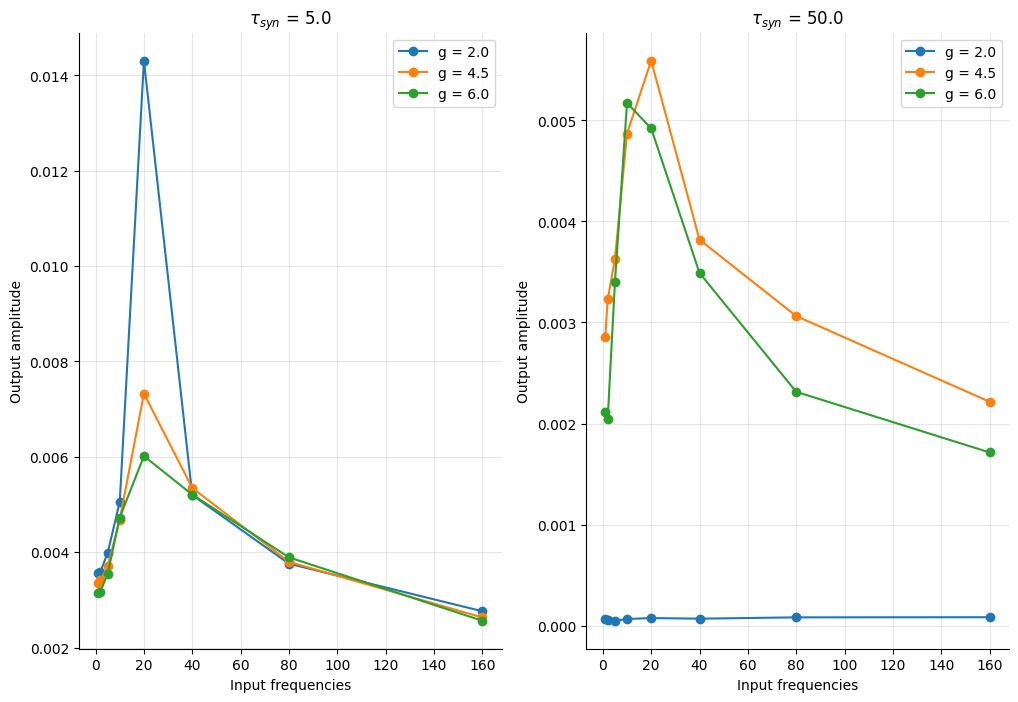

In [ ]:
plot_amplitude_curve(adap_sims)

In [ ]:
# g1 = sns.relplot(x="input_vals",y="population_FR",col=r'$\tau_{syn}$',hue='g',style='adaptation_strength',data=all_sims,kind='line',marker='o',facet_kws={'sharey':False},palette='tab10')


In [ ]:
lif_sims.loc[lif_sims['g']==2]

,input_frequencies,output_amplitude,g,$\tau_{syn}$,adaptation_strength
0,1.0,0.004868,2.0,5.0,0
1,2.0,0.004833,2.0,5.0,0
2,5.0,0.004935,2.0,5.0,0
3,10.0,0.004988,2.0,5.0,0
4,20.0,0.005780,2.0,5.0,0
5,40.0,0.005291,2.0,5.0,0
6,80.0,0.004003,2.0,5.0,0
7,160.0,0.003093,2.0,5.0,0
0,1.0,0.000005,2.0,50.0,0
1,2.0,0.000015,2.0,50.0,0


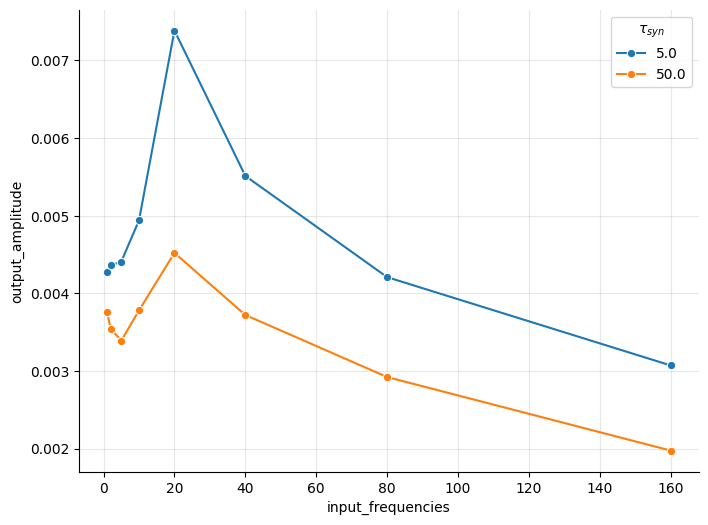

In [ ]:
fig,ax = plt.subplots(1,1,figsize=(8,6))
sns.lineplot(x="input_frequencies",y="output_amplitude",hue=r'$\tau_{syn}$',data=lif_sims.loc[lif_sims['g']==4.5],palette='tab10',marker='o',ax=ax)
ax.spines.top.set_visible(False)
ax.spines.right.set_visible(False)
ax.grid(alpha=0.3)

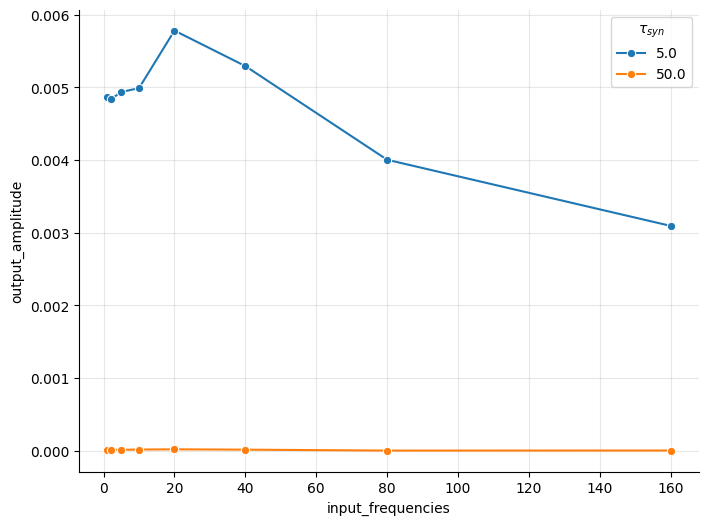

In [ ]:
fig,ax = plt.subplots(1,1,figsize=(8,6))
sns.lineplot(x="input_frequencies",y="output_amplitude",hue=r'$\tau_{syn}$',data=lif_sims.loc[lif_sims['g']==2.0],palette='tab10',marker='o',ax=ax)
ax.spines.top.set_visible(False)
ax.spines.right.set_visible(False)
ax.grid(alpha=0.3)

In [ ]:
def create_amplitude_spectrum(
    tau_syn,
    g,
    adaptation_strength,
    input_level=1.0,
    sim_time=4*second,
    transient=1*second
):

    # One simulation, with NO oscillatory input
    monitor, spm = run_network(
        input_level=input_level,
        tau_syn=tau_syn,
        g=g,
        adaptation_strength=adaptation_strength,
        sim_time=sim_time,
        record_spikes=False,          # faster; not needed for spectrum
        modulation_frequency=None,    # NO oscillatory input
        modulation_depth=0.0
    )

    t = np.asarray(monitor.t / second)
    rate = np.asarray(monitor.rate / Hz)

    # Remove transient
    mask = t >= float(transient / second)
    t = t[mask]
    rate = rate[mask]

    # Remove DC/mean
    rate_centered = rate - np.mean(rate)

    N_samples = len(rate_centered)
    dt = np.mean(np.diff(t))

    # Full FFT
    fft_values = np.fft.rfft(rate_centered)

    frequencies = np.fft.rfftfreq(
        N_samples,
        d=dt
    )

    # Fourier amplitude
    amplitudes = (2.0 / N_samples) * np.abs(fft_values)

    # Normalize
    amplitudes = amplitudes / np.sum(amplitudes)

    return frequencies, amplitudes

tau_syn = 5 ms, run 1/10
tau_syn = 5 ms, run 2/10
tau_syn = 5 ms, run 3/10
tau_syn = 5 ms, run 4/10
tau_syn = 5 ms, run 5/10
tau_syn = 5 ms, run 6/10
tau_syn = 5 ms, run 7/10
tau_syn = 5 ms, run 8/10
tau_syn = 5 ms, run 9/10
tau_syn = 5 ms, run 10/10
tau_syn = 5 ms | entropy = 0.8376 ± 0.0184
tau_syn = 10 ms, run 1/10
tau_syn = 10 ms, run 2/10
tau_syn = 10 ms, run 3/10
tau_syn = 10 ms, run 4/10
tau_syn = 10 ms, run 5/10
tau_syn = 10 ms, run 6/10
tau_syn = 10 ms, run 7/10
tau_syn = 10 ms, run 8/10
tau_syn = 10 ms, run 9/10
tau_syn = 10 ms, run 10/10
tau_syn = 10 ms | entropy = 0.8517 ± 0.0191
tau_syn = 20 ms, run 1/10
tau_syn = 20 ms, run 2/10
tau_syn = 20 ms, run 3/10
tau_syn = 20 ms, run 4/10
tau_syn = 20 ms, run 5/10
tau_syn = 20 ms, run 6/10
tau_syn = 20 ms, run 7/10
tau_syn = 20 ms, run 8/10
tau_syn = 20 ms, run 9/10
tau_syn = 20 ms, run 10/10
tau_syn = 20 ms | entropy = 0.8898 ± 0.0137
tau_syn = 50 ms, run 1/10
tau_syn = 50 ms, run 2/10
tau_syn = 50 ms, run 3/10
tau_syn = 50 ms, r

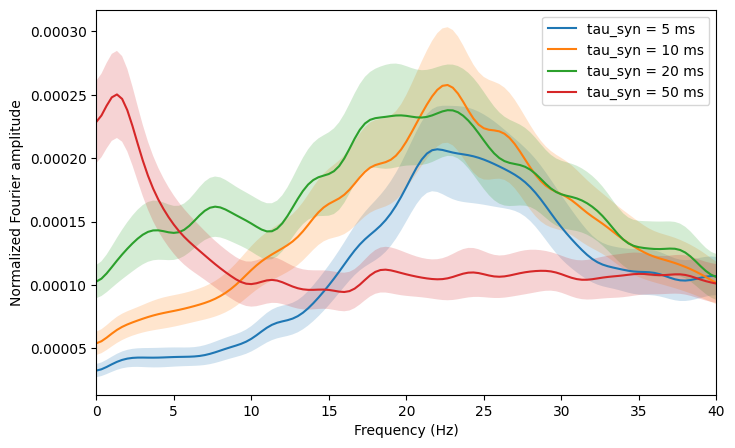

In [ ]:
from scipy.ndimage import gaussian_filter1d

tau_syn_values = [5, 10, 20, 50] * ms
n_runs = 10

plt.figure(figsize=(8, 5))

for tau_syn_value in tau_syn_values:

    all_amplitudes = []
    all_entropies = []

    for run_idx in range(n_runs):

        print(
            f"tau_syn = {tau_syn_value/ms:.0f} ms, "
            f"run {run_idx + 1}/{n_runs}"
        )

        frequencies, amplitudes = create_amplitude_spectrum(
            tau_syn=tau_syn_value,
            g=g,
            adaptation_strength=adaptation_strength,
            input_level=input_level
        )

        all_amplitudes.append(amplitudes)

        # -----------------------------------------
        # Spectral entropy for THIS simulation
        # Only 0–40 Hz
        # -----------------------------------------

        mask = (frequencies > 0) & (frequencies <= 40)

        power = amplitudes[mask] ** 2
        p = power / np.sum(power)

        H = -np.sum(p * np.log(p + 1e-12))
        H_norm = H / np.log(len(p))

        all_entropies.append(H_norm)

    # runs x frequencies
    all_amplitudes = np.asarray(all_amplitudes)

    # Average spectrum across simulations
    mean_amplitude = np.mean(all_amplitudes, axis=0)

    # Standard error across simulations
    sem_amplitude = (
        np.std(all_amplitudes, axis=0, ddof=1)
        / np.sqrt(n_runs)
    )

    # Smooth ONLY for visualization
    mean_smooth = gaussian_filter1d(
        mean_amplitude,
        sigma=3
    )

    sem_smooth = gaussian_filter1d(
        sem_amplitude,
        sigma=3
    )

    # Mean line
    plt.plot(
        frequencies,
        mean_smooth,
        label=f'tau_syn = {tau_syn_value/ms:.0f} ms'
    )

    # Shaded SEM
    plt.fill_between(
        frequencies,
        mean_smooth - sem_smooth,
        mean_smooth + sem_smooth,
        alpha=0.2
    )

    # Entropy results
    print(
        f"tau_syn = {tau_syn_value/ms:.0f} ms | "
        f"entropy = {np.mean(all_entropies):.4f} "
        f"± {np.std(all_entropies, ddof=1):.4f}"
    )


plt.xlabel('Frequency (Hz)')
plt.ylabel('Normalized Fourier amplitude')
plt.xlim(0, 40)
plt.legend()
plt.show()

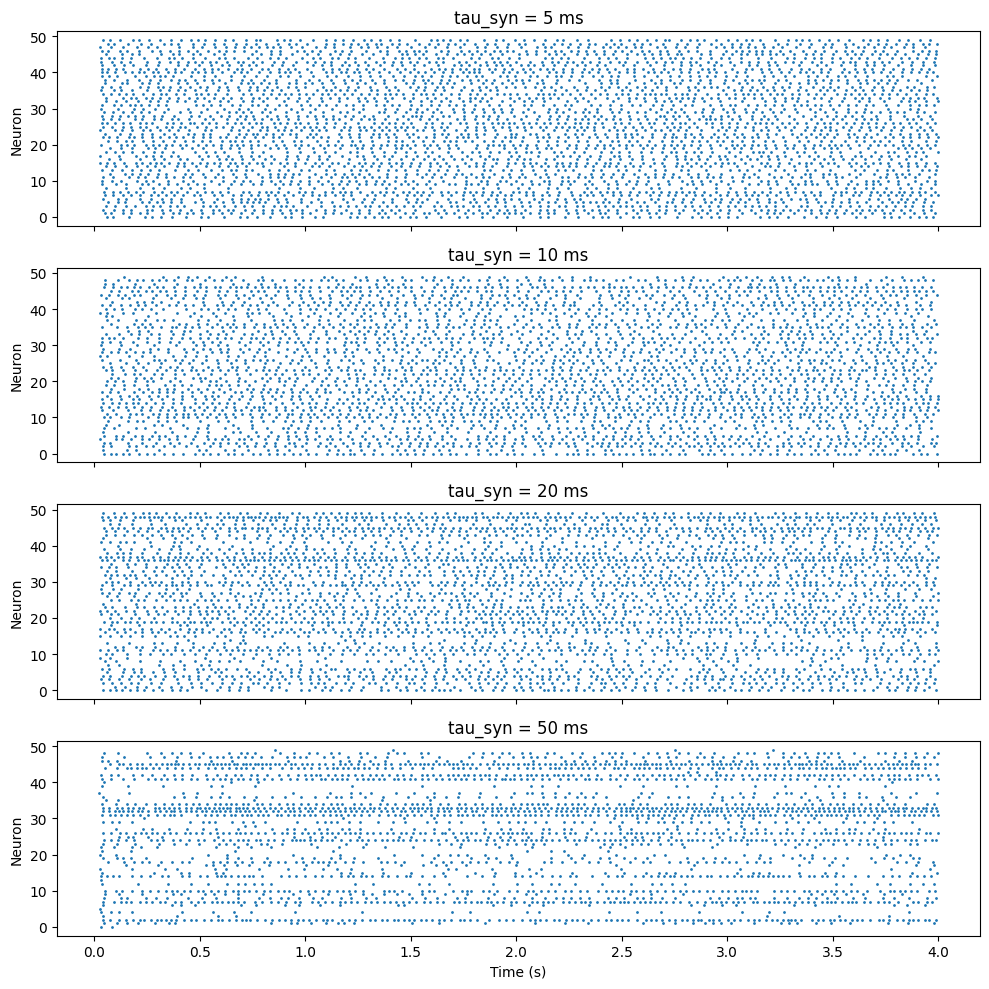

In [ ]:
tau_syn_values = [5, 10, 20, 50] * ms

fig, axes = plt.subplots(
    4, 1,
    figsize=(10, 10),
    sharex=True
)

for ax, tau_syn_value in zip(axes, tau_syn_values):

    monitor, spm = run_network(
        input_level=input_level,
        tau_syn=tau_syn_value,
        g=g,
        adaptation_strength=adaptation_strength,
        sim_time=4*second,
        record_spikes=True,
        modulation_frequency=None,   # NO oscillatory input
        modulation_depth=0.0
    )

    # Raster plot
    ax.plot(
        spm.t / second,
        spm.i,
        '.',
        markersize=2
    )

    ax.set_ylabel('Neuron')
    ax.set_title(
        f'tau_syn = {tau_syn_value/ms:.0f} ms'
    )



axes[-1].set_xlabel('Time (s)')

plt.tight_layout()
plt.show()

In [ ]:
def get_normalized_amplitude_at_frequency(
    tau_syn,
    g,
    target_frequency,
    adaptation_strength,
    input_level,
    sim_time=4*second,
    transient=1*second,
    normalization_min_frequency=0.0,
    normalization_max_frequency=40.0
):

    # --------------------------------------------------------
    # Run network with random Poisson input only
    # --------------------------------------------------------

    monitor, _ = run_network(
        input_level=input_level,
        tau_syn=tau_syn,
        g=g,
        adaptation_strength=adaptation_strength,
        sim_time=sim_time,
        record_spikes=False,
        modulation_frequency=None,   # NO oscillatory input
        modulation_depth=0.0
    )

    # --------------------------------------------------------
    # Get population firing rate
    # --------------------------------------------------------

    t = np.asarray(monitor.t / second)
    rate = np.asarray(monitor.rate / Hz)

    # --------------------------------------------------------
    # Remove transient
    # --------------------------------------------------------

    mask = t >= float(transient / second)

    t = t[mask]
    rate = rate[mask]

    # --------------------------------------------------------
    # Remove mean (DC component)
    # --------------------------------------------------------

    rate_centered = rate - np.mean(rate)

    # --------------------------------------------------------
    # FFT
    # --------------------------------------------------------

    N_samples = len(rate_centered)
    dt = np.mean(np.diff(t))

    fft_values = np.fft.rfft(rate_centered)

    fft_frequencies = np.fft.rfftfreq(
        N_samples,
        d=dt
    )

    # --------------------------------------------------------
    # Fourier amplitude
    # --------------------------------------------------------

    amplitudes = np.abs(fft_values)

    # --------------------------------------------------------
    # Restrict normalization range
    # --------------------------------------------------------

    normalization_mask = (
        (fft_frequencies > normalization_min_frequency)
        &
        (fft_frequencies <= normalization_max_frequency)
    )

    total_amplitude = np.sum(
        amplitudes[normalization_mask]
    )

    # --------------------------------------------------------
    # Find closest FFT bin to target frequency
    # --------------------------------------------------------

    target_idx = np.argmin(
        np.abs(
            fft_frequencies - target_frequency
        )
    )

    # --------------------------------------------------------
    # Normalized amplitude
    # --------------------------------------------------------

    normalized_amplitude = (
        amplitudes[target_idx]
        / total_amplitude
    )

    return normalized_amplitude

CPU cores visible: 44
Workers being used: 42
Total simulations: 1400


[Parallel(n_jobs=42)]: Using backend LokyBackend with 42 concurrent workers.
[Parallel(n_jobs=42)]: Done   1 tasks      | elapsed:   25.0s
[Parallel(n_jobs=42)]: Done  14 tasks      | elapsed:   26.2s
[Parallel(n_jobs=42)]: Done  29 tasks      | elapsed:   26.3s
[Parallel(n_jobs=42)]: Done  44 tasks      | elapsed:   32.0s
[Parallel(n_jobs=42)]: Done  61 tasks      | elapsed:   33.7s
[Parallel(n_jobs=42)]: Done  78 tasks      | elapsed:   33.7s
[Parallel(n_jobs=42)]: Done  97 tasks      | elapsed:   52.2s
[Parallel(n_jobs=42)]: Done 116 tasks      | elapsed:   52.3s
[Parallel(n_jobs=42)]: Done 137 tasks      | elapsed:   59.6s
[Parallel(n_jobs=42)]: Done 158 tasks      | elapsed:   59.8s
[Parallel(n_jobs=42)]: Done 181 tasks      | elapsed:  1.1min
[Parallel(n_jobs=42)]: Done 204 tasks      | elapsed:  1.1min
[Parallel(n_jobs=42)]: Done 229 tasks      | elapsed:  1.2min
[Parallel(n_jobs=42)]: Done 254 tasks      | elapsed:  1.3min
[Parallel(n_jobs=42)]: Done 281 tasks      | elapsed:  

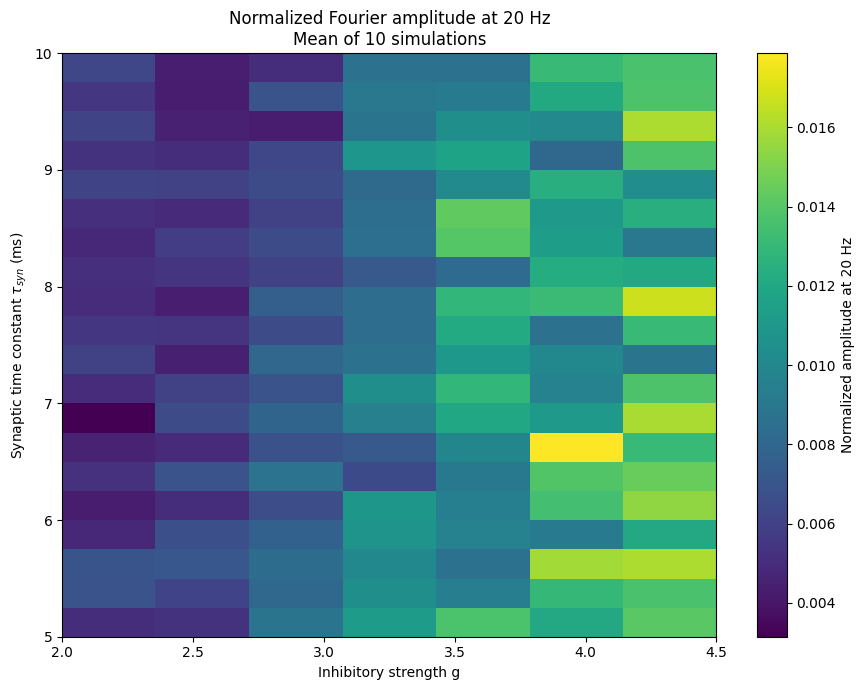

In [ ]:
# ============================================================
# PARALLEL g x tau_syn PARAMETER SWEEP
# ============================================================

from joblib import Parallel, delayed
import numpy as np
import os


# ------------------------------------------------------------
# SETTINGS
# ------------------------------------------------------------
# Parameter ranges
g_values = np.linspace(2.0, 4.5, 7, 15)
tau_values = np.linspace(5.0, 10.0, 20, 50) * ms

# Fourier frequency we care about
target_frequency = 20.0  # Hz


normalization_min_frequency = 0.0
normalization_max_frequency = 40.0

# Number of independent Poisson realizations
n_runs = 10

# Number of parallel processes
n_workers = 42

print("CPU cores visible:", os.cpu_count())
print("Workers being used:", n_workers)


# ------------------------------------------------------------
# ONE INDEPENDENT JOB
# ------------------------------------------------------------

def run_one_heatmap_job(
    tau_ms,
    g_value,
    run_idx
):

    # Convert plain float back into Brian2 quantity
    tau = tau_ms * ms

    value = get_normalized_amplitude_at_frequency(
        tau_syn=tau,
        g=g_value,
        target_frequency=target_frequency,
        adaptation_strength=adaptation_strength,
        input_level=input_level,
        normalization_min_frequency=normalization_min_frequency,
        normalization_max_frequency=normalization_max_frequency
    )

    return (
        tau_ms,
        g_value,
        run_idx,
        value
    )


# ------------------------------------------------------------
# BUILD LIST OF ALL JOBS
# ------------------------------------------------------------

jobs = []

for tau in tau_values:

    for g_value in g_values:

        for run_idx in range(n_runs):

            jobs.append(
                (
                    float(tau / ms),
                    float(g_value),
                    run_idx
                )
            )


print("Total simulations:", len(jobs))


# ------------------------------------------------------------
# RUN IN PARALLEL
# ------------------------------------------------------------

results = Parallel(
    n_jobs=n_workers,
    backend="loky",
    verbose=10
)(
    delayed(run_one_heatmap_job)(
        tau_ms,
        g_value,
        run_idx
    )
    for tau_ms, g_value, run_idx in jobs
)


# ============================================================
# RECONSTRUCT HEATMAP
# ============================================================

heatmap = np.zeros(
    (
        len(tau_values),
        len(g_values)
    )
)

heatmap_std = np.zeros_like(heatmap)


for i, tau in enumerate(tau_values):

    tau_ms = float(tau / ms)

    for j, g_value in enumerate(g_values):

        values = [
            value
            for result_tau,
                result_g,
                run_idx,
                value in results

            if np.isclose(result_tau, tau_ms)
            and np.isclose(result_g, g_value)
        ]

        heatmap[i, j] = np.mean(values)
        heatmap_std[i, j] = np.std(values)


# ============================================================
# PLOT MEAN HEATMAP
# ============================================================

plt.figure(figsize=(9, 7))

im = plt.imshow(
    heatmap,
    origin='lower',
    aspect='auto',
    extent=[
        g_values[0],
        g_values[-1],
        tau_values[0] / ms,
        tau_values[-1] / ms
    ]
)

plt.colorbar(
    im,
    label=(
        f'Normalized amplitude at '
        f'{target_frequency:.0f} Hz'
    )
)

plt.xlabel('Inhibitory strength g')

plt.ylabel(
    r'Synaptic time constant $\tau_{syn}$ (ms)'
)

plt.title(
    f'Normalized Fourier amplitude at '
    f'{target_frequency:.0f} Hz\n'
    f'Mean of {n_runs} simulations'
)

plt.tight_layout()
plt.show()